# Label Flipping: A Data Poisoning Attack on a Classifier

Label flipping inverts a fraction of training labels while leaving the features unchanged. This notebook
trains a classifier on synthetic data, then flips 0-50% of the training labels and measures the effect on
test accuracy and the decision boundary.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

SEED = 1337
np.random.seed(SEED)

# --- color palette ---
bg_dark      = "#141d2b"
grid_grey    = "#a4b1cd"
text_white   = "#ffffff"
pink_primary = "#ff2e88"  # headline accent / 0% (clean) decision boundary
pink_class0  = "#c724b1"  # Class 0 data points
pink_class1  = "#ffb3c6"  # Class 1 data points
pink_alert   = "#ff1053"  # flipped-label highlight
pink_accent2 = "#8e2984"  # boundary accent (deep plum)
pink_accent3 = "#ff8fb3"  # boundary accent (coral pink)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({
    "figure.facecolor": bg_dark,
    "axes.facecolor": bg_dark,
    "axes.edgecolor": grid_grey,
    "axes.labelcolor": text_white,
    "text.color": text_white,
    "xtick.color": grid_grey,
    "ytick.color": grid_grey,
    "grid.color": grid_grey,
    "grid.alpha": 0.1,
    "legend.facecolor": bg_dark,
    "legend.edgecolor": grid_grey,
    "legend.frameon": True,
    "legend.framealpha": 1.0,
    "legend.labelcolor": text_white,
})

print("Setup complete.")

Setup complete.


## 1. Synthetic dataset

`make_blobs` generates two Gaussian clusters in a 2D feature space, standing in for two sentiment classes
(0 = negative, 1 = positive).

In [3]:
n_samples = 1000
centers = [(0, 5), (5, 0)]
X, y = make_blobs(n_samples=n_samples, centers=centers, n_features=2, cluster_std=1.25, random_state=SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 700 samples | Test: 300 samples


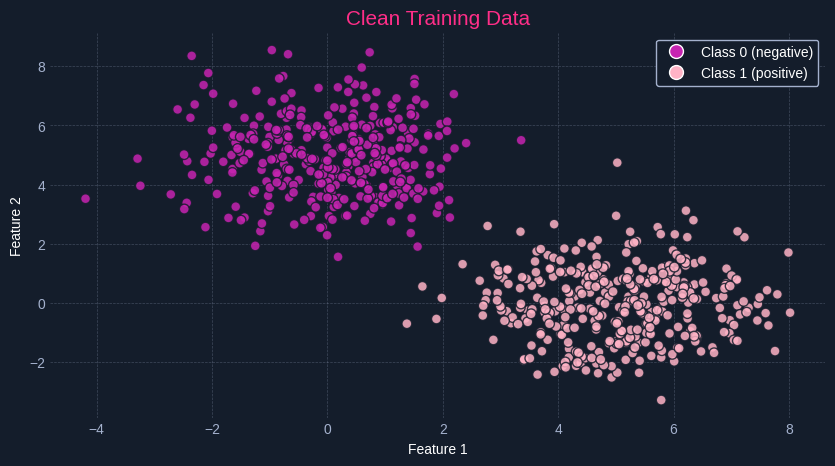

In [4]:
def plot_data(X, y, title):
    plt.figure(figsize=(10, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y,
                cmap=plt.cm.colors.ListedColormap([pink_class0, pink_class1]),
                edgecolors=bg_dark, s=50, alpha=0.85)
    plt.title(title, fontsize=15, color=pink_primary)
    plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
    handles = [
        plt.Line2D([0], [0], marker="o", color="w", label="Class 0 (negative)",
                   markersize=10, markerfacecolor=pink_class0, linestyle="None"),
        plt.Line2D([0], [0], marker="o", color="w", label="Class 1 (positive)",
                   markersize=10, markerfacecolor=pink_class1, linestyle="None"),
    ]
    plt.legend(handles=handles)
    plt.grid(True, color=grid_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()

plot_data(X_train, y_train, "Clean Training Data")

Baseline accuracy on clean test set: 0.9933


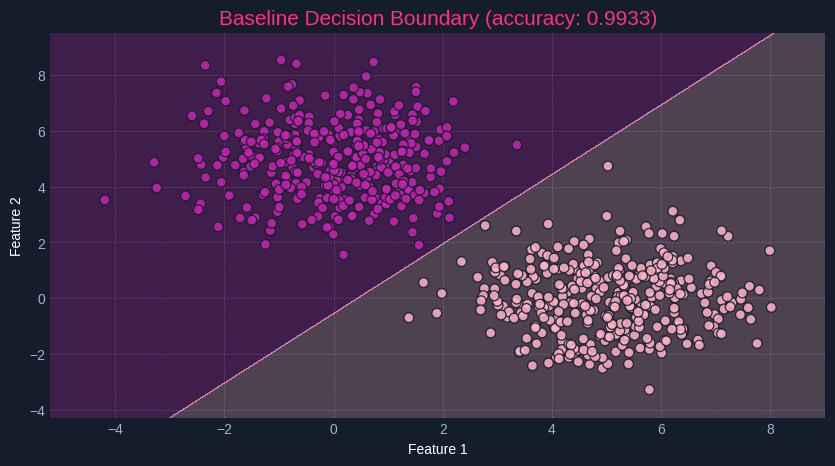

In [5]:
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(10, 5))
    plt.contourf(xx, yy, Z, cmap=plt.cm.colors.ListedColormap([pink_class0, pink_class1]), alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y,
                cmap=plt.cm.colors.ListedColormap([pink_class0, pink_class1]),
                edgecolors=bg_dark, s=50, alpha=0.85)
    plt.title(title, fontsize=15, color=pink_primary)
    plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
    plt.xlim(xx.min(), xx.max()); plt.ylim(yy.min(), yy.max())
    plt.grid(True, color=grid_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()
    return xx, yy

baseline_model = LogisticRegression(random_state=SEED)
baseline_model.fit(X_train, y_train)
baseline_accuracy = accuracy_score(y_test, baseline_model.predict(X_test))
print(f"Baseline accuracy on clean test set: {baseline_accuracy:.4f}")

xx, yy = plot_decision_boundary(baseline_model, X_train, y_train,
                                 f"Baseline Decision Boundary (accuracy: {baseline_accuracy:.4f})")
mesh_points = np.c_[xx.ravel(), yy.ravel()]

## 3. The attack: `flip_labels`

Selects a `poison_percentage` fraction of training indices via a seeded RNG and inverts each selected label
(0↔1).

In [6]:
def flip_labels(y, poison_percentage, seed=SEED):
    """Randomly flip `poison_percentage` fraction of binary labels in y."""
    if not 0 <= poison_percentage <= 1:
        raise ValueError("poison_percentage must be between 0 and 1.")

    n_samples = len(y)
    n_to_flip = int(n_samples * poison_percentage)
    if n_to_flip == 0:
        return y.copy(), np.array([], dtype=int)

    rng = np.random.default_rng(seed)
    flipped_indices = rng.choice(n_samples, size=n_to_flip, replace=False)

    y_poisoned = y.copy()
    original = y_poisoned[flipped_indices]
    y_poisoned[flipped_indices] = np.where(original == 0, 1, 0)
    return y_poisoned, flipped_indices


def plot_poisoned_data(X, y_poisoned, flipped_indices, title):
    plt.figure(figsize=(10, 6))
    mask = np.ones(len(y_poisoned), dtype=bool)
    mask[flipped_indices] = False

    plt.scatter(X[mask, 0], X[mask, 1], c=y_poisoned[mask],
                cmap=plt.cm.colors.ListedColormap([pink_class0, pink_class1]),
                edgecolors=bg_dark, s=50, alpha=0.6, label="Unchanged label")
    if len(flipped_indices) > 0:
        plt.scatter(X[flipped_indices, 0], X[flipped_indices, 1], c=y_poisoned[flipped_indices],
                    cmap=plt.cm.colors.ListedColormap([pink_class0, pink_class1]),
                    edgecolors=pink_alert, linewidths=1.5, marker="X", s=100, alpha=0.95,
                    label="Flipped label")

    plt.title(title, fontsize=15, color=pink_primary)
    plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, color=grid_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()

## 4. Single-run demo: 20% poisoned

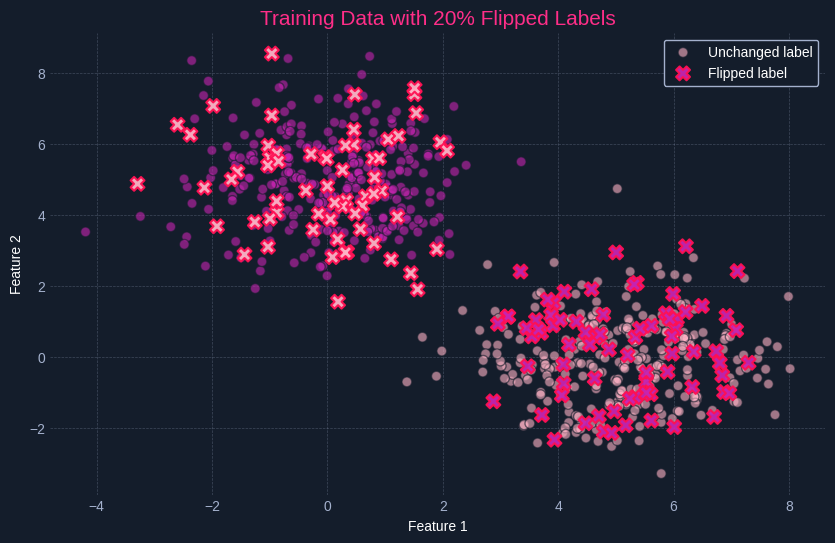

Accuracy on clean test set (20% poisoned): 0.9933
Baseline accuracy was:                     0.9933


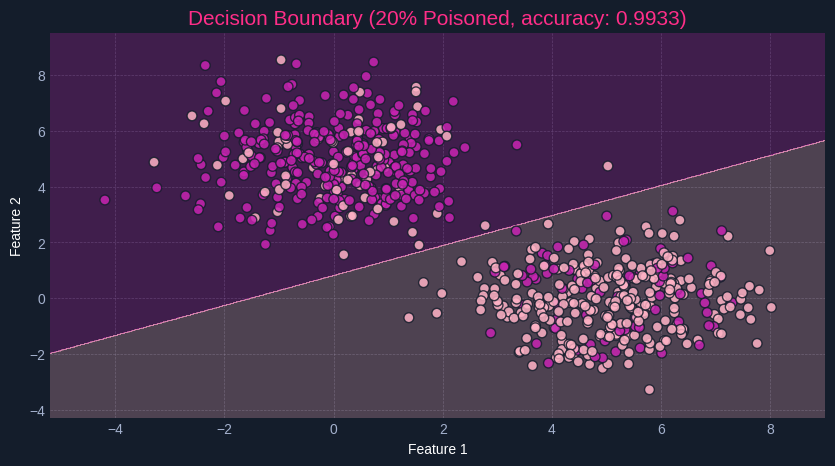

(array([[-5.19192233, -5.17192233, -5.15192233, ...,  8.96807767,
          8.98807767,  9.00807767],
        [-5.19192233, -5.17192233, -5.15192233, ...,  8.96807767,
          8.98807767,  9.00807767],
        [-5.19192233, -5.17192233, -5.15192233, ...,  8.96807767,
          8.98807767,  9.00807767],
        ...,
        [-5.19192233, -5.17192233, -5.15192233, ...,  8.96807767,
          8.98807767,  9.00807767],
        [-5.19192233, -5.17192233, -5.15192233, ...,  8.96807767,
          8.98807767,  9.00807767],
        [-5.19192233, -5.17192233, -5.15192233, ...,  8.96807767,
          8.98807767,  9.00807767]], shape=(691, 711)),
 array([[-4.27877035, -4.27877035, -4.27877035, ..., -4.27877035,
         -4.27877035, -4.27877035],
        [-4.25877035, -4.25877035, -4.25877035, ..., -4.25877035,
         -4.25877035, -4.25877035],
        [-4.23877035, -4.23877035, -4.23877035, ..., -4.23877035,
         -4.23877035, -4.23877035],
        ...,
        [ 9.48122965,  9.48122965,  

In [15]:
poison_rate_demo = 0.20
y_train_poisoned_demo, flipped_idx_demo = flip_labels(y_train, poison_rate_demo)

plot_poisoned_data(X_train, y_train_poisoned_demo, flipped_idx_demo,
                    f"Training Data with {poison_rate_demo*100:.0f}% Flipped Labels")

poisoned_model_demo = LogisticRegression(random_state=SEED)
poisoned_model_demo.fit(X_train, y_train_poisoned_demo)
poisoned_accuracy_demo = accuracy_score(y_test, poisoned_model_demo.predict(X_test))
print(f"Accuracy on clean test set ({poison_rate_demo*100:.0f}% poisoned): {poisoned_accuracy_demo:.4f}")
print(f"Baseline accuracy was:                     {baseline_accuracy:.4f}")

plot_decision_boundary(poisoned_model_demo, X_train, y_train_poisoned_demo,
                        f"Decision Boundary ({poison_rate_demo*100:.0f}% Poisoned, accuracy: {poisoned_accuracy_demo:.4f})")

## 5. Sweeping the poisoning rate (0% → 50%)

Trains one model per poisoning rate and records test accuracy and the decision boundary for each.

In [16]:
poison_rates = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
boundary_colors = {
    0.0: pink_primary, 0.10: pink_accent3, 0.20: pink_class1,
    0.30: pink_accent2, 0.40: pink_class0, 0.50: pink_alert,
}

accuracies = {}
boundaries = {}

for rate in poison_rates:
    if rate == 0.0:
        model = baseline_model
        acc = baseline_accuracy
        y_poisoned_run = y_train
    else:
        y_poisoned_run, _ = flip_labels(y_train, rate)
        model = LogisticRegression(random_state=SEED)
        model.fit(X_train, y_poisoned_run)
        acc = accuracy_score(y_test, model.predict(X_test))

    accuracies[rate] = acc
    boundaries[rate] = model.predict(mesh_points).reshape(xx.shape)
    print(f"{rate*100:>4.0f}% poisoned -> test accuracy: {acc:.4f}")

   0% poisoned -> test accuracy: 0.9933
  10% poisoned -> test accuracy: 0.9933
  20% poisoned -> test accuracy: 0.9933
  30% poisoned -> test accuracy: 0.9933
  40% poisoned -> test accuracy: 0.9933
  50% poisoned -> test accuracy: 0.4767


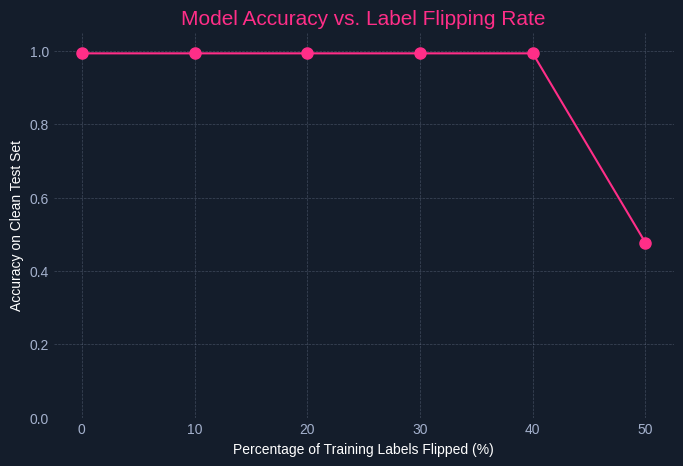

In [17]:
# Accuracy vs. poisoning rate
plt.figure(figsize=(8, 5))
rates_sorted = sorted(accuracies)
plt.plot([r * 100 for r in rates_sorted], [accuracies[r] for r in rates_sorted],
         marker="o", linestyle="-", color=pink_primary, markersize=8)
plt.title("Model Accuracy vs. Label Flipping Rate", fontsize=15, color=pink_primary)
plt.xlabel("Percentage of Training Labels Flipped (%)")
plt.ylabel("Accuracy on Clean Test Set")
plt.ylim(0, 1.05)
plt.grid(True, color=grid_grey, linestyle="--", linewidth=0.5, alpha=0.3)
plt.show()

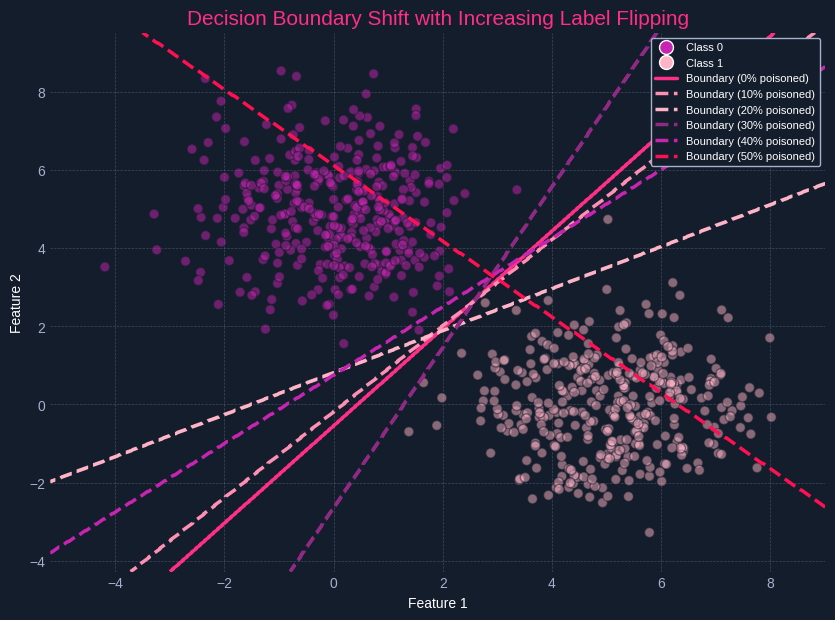

In [18]:
# All decision boundaries overlaid
plt.figure(figsize=(10, 7))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
            cmap=plt.cm.colors.ListedColormap([pink_class0, pink_class1]),
            edgecolors=bg_dark, s=50, alpha=0.5, label="Clean data points")

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label="Class 0",
               markersize=10, markerfacecolor=pink_class0, linestyle="None"),
    plt.Line2D([0], [0], marker="o", color="w", label="Class 1",
               markersize=10, markerfacecolor=pink_class1, linestyle="None"),
]
for rate in poison_rates:
    style = "solid" if rate == 0.0 else "dashed"
    plt.contour(xx, yy, boundaries[rate], levels=[0.5], colors=[boundary_colors[rate]],
                linestyles=[style], linewidths=[2.5])
    legend_handles.append(plt.Line2D([0], [0], color=boundary_colors[rate], lw=2.5, linestyle=style,
                                      label=f"Boundary ({rate*100:.0f}% poisoned)"))

plt.title("Decision Boundary Shift with Increasing Label Flipping", fontsize=15, color=pink_primary)
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend(handles=legend_handles, fontsize=8)
plt.grid(True, color=grid_grey, linestyle="--", linewidth=0.5, alpha=0.3)
plt.xlim(xx.min(), xx.max()); plt.ylim(yy.min(), yy.max())
plt.show()

## Results

Test accuracy stays close to baseline across most poisoning rates in this run; the decision boundary shifts
at every rate tested. Corresponds to OWASP LLM03: Training Data Poisoning.